In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format","{:,.2f}".format)
print("Libraries Imported Successfully!!")

Libraries Imported Successfully!!


In [2]:
conn = sqlite3.connect("../database/ecommerce.db")
customers = pd.read_sql_query(
    "SELECT * FROM customers",
    conn
)
products = pd.read_sql_query(
    "SELECT * FROM Products",
    conn
)
orders = pd.read_csv("../data/Orders.csv")
payments = pd.read_csv("../data/Payments.csv")

In [3]:
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Payments:", payments.shape)

Customers: (20, 7)
Products: (15, 5)
Orders: (20, 5)
Payments: (20, 5)


In [4]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'product_id', 'quantity', 'order_date']

Products columns:
['product_id', 'product_name', 'category', 'price', 'stock_quantity']


In [5]:
merged = orders.merge(
    products,
    on="product_id",
    how="left",
    validate="many_to_one"
)
print("Merged dataset shape:", merged.shape)
merged.head()

Merged dataset shape: (20, 9)


,order_id,customer_id,product_id,quantity,order_date,product_name,category,price,stock_quantity
0,1,1,1,1,2025-04-01,iPhone 15,Electronics,"79,999.00",50
1,2,2,6,2,2025-04-02,The Psychology of Money,Books,399.00,200
2,3,3,4,1,2025-04-03,Nike Running Shoes,Sports,"4,999.00",80
3,4,4,8,1,2025-04-04,Mixer Grinder,Home & Kitchen,"3,499.00",60
4,5,5,2,1,2025-04-05,Samsung Galaxy S24,Electronics,"69,999.00",45


In [6]:
print("Unmatched product records:")
print(
    merged["product_name"].isna().sum()
    if "product_name" in merged.columns
    else "Check your product-name column"
)

Unmatched product records:
0


In [8]:
total_orders = orders["order_id"].nunique()
print("Total Orders:", total_orders)

Total Orders: 20


In [9]:
total_quantity_sold = orders["quantity"].sum()
print("Total Quantity Sold:", total_quantity_sold)

Total Quantity Sold: 32


In [10]:
merged["revenue"] = (
    merged["quantity"] * merged["price"]
)
total_revenue = merged["revenue"].sum()
print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹349,868.00


In [11]:
order_revenue = (
    merged.groupby("order_id")["revenue"]
    .sum()
)
average_order_value = order_revenue.mean()
print(f"Average Order Value: ₹{average_order_value:,.2f}")

Average Order Value: ₹17,493.40


In [12]:
product_performance = (
    merged.groupby("product_name")
    .agg(
        units_sold=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        average_unit_price=("price", "mean")
    )
    .sort_values(
        by="total_revenue",
        ascending=False
    )
)
product_performance


,units_sold,total_revenue,average_unit_price
product_name,,,
iPhone 15,2,"159,998.00","79,999.00"
Samsung Galaxy S24,2,"139,998.00","69,999.00"
Nike Running Shoes,3,"14,997.00","4,999.00"
Mixer Grinder,2,"6,998.00","3,499.00"
Air Fryer,1,"5,999.00","5,999.00"
Adidas T-Shirt,2,"3,998.00","1,999.00"
Cricket Bat,1,"2,999.00","2,999.00"
Laptop Backpack,2,"2,598.00","1,299.00"
Boat Headphones,1,"2,499.00","2,499.00"


In [13]:
top_5_products = product_performance.head(5)
top_5_products

,units_sold,total_revenue,average_unit_price
product_name,,,
iPhone 15,2,"159,998.00","79,999.00"
Samsung Galaxy S24,2,"139,998.00","69,999.00"
Nike Running Shoes,3,"14,997.00","4,999.00"
Mixer Grinder,2,"6,998.00","3,499.00"
Air Fryer,1,"5,999.00","5,999.00"


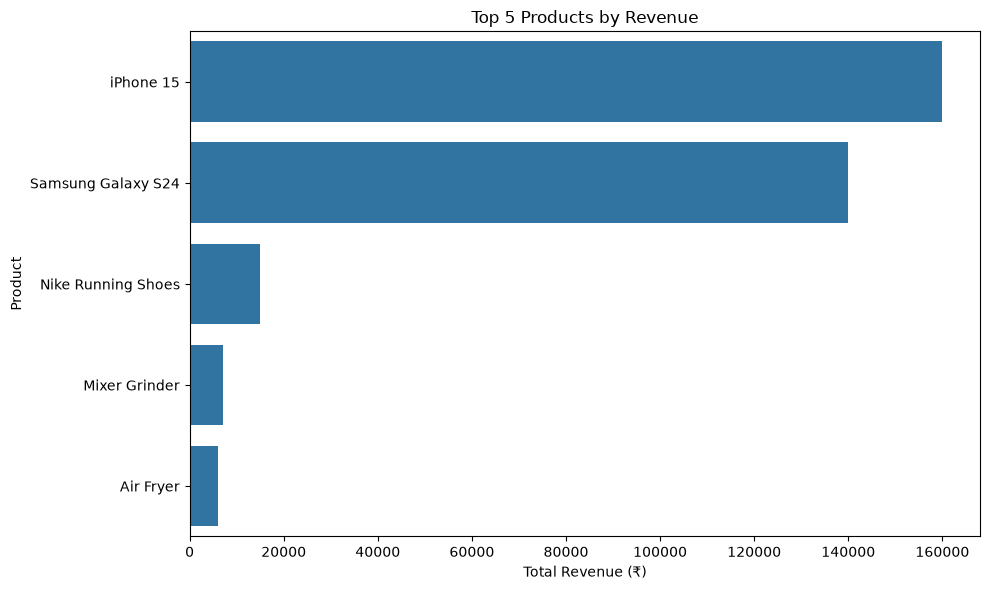

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_5_products.reset_index(),
    x="total_revenue",
    y="product_name"
)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Total Revenue (₹)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [15]:
category_performance = (
    merged.groupby("category")
    .agg(
        units_sold=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        product_count=("product_id", "nunique")
    )
    .sort_values(
        by="total_revenue",
        ascending=False
    )
)

category_performance

,units_sold,total_revenue,product_count
category,,,
Electronics,5,"302,495.00",3
Sports,4,"17,996.00",2
Home & Kitchen,3,"12,997.00",2
Fashion,4,"6,596.00",2
Beauty,7,"3,593.00",2
Toys,3,"3,497.00",2
Books,6,"2,694.00",2


In [18]:
customer_orders = orders.merge(
    customers,
    on="customer_id",
    how="left",
    validate="many_to_one"
)

print(customer_orders.shape)

customer_orders.head()

(20, 11)


,order_id,customer_id,product_id,quantity,order_date,name,age,gender,city,state,signup_date
0,1,1,1,1,2025-04-01,Aarav Sharma,24,Male,Delhi,Delhi,2025-01-10
1,2,2,6,2,2025-04-02,Priya Verma,22,Female,Mumbai,Maharashtra,2025-02-15
2,3,3,4,1,2025-04-03,Rahul Singh,27,Male,Bangalore,Karnataka,2025-03-01
3,4,4,8,1,2025-04-04,Ananya Gupta,23,Female,Hyderabad,Telangana,2025-01-25
4,5,5,2,1,2025-04-05,Vikram Patel,29,Male,Ahmedabad,Gujarat,2025-02-12


In [19]:
customer_metrics = (
    merged.groupby("customer_id")
    .agg(
        total_spending=("revenue", "sum"),
        units_purchased=("quantity", "sum"),
        distinct_products=("product_id", "nunique"),
        total_orders=("order_id", "nunique")
    )
)

customer_metrics["average_order_value"] = (
    customer_metrics["total_spending"]
    / customer_metrics["total_orders"].replace(0, np.nan)
)

customer_metrics = customer_metrics.sort_values(
    by="total_spending",
    ascending=False
)

customer_metrics.head(10)

,total_spending,units_purchased,distinct_products,total_orders,average_order_value
customer_id,,,,,
1,"79,999.00",1,1,1,"79,999.00"
11,"79,999.00",1,1,1,"79,999.00"
5,"69,999.00",1,1,1,"69,999.00"
17,"69,999.00",1,1,1,"69,999.00"
19,"9,998.00",2,1,1,"9,998.00"
15,"5,999.00",1,1,1,"5,999.00"
3,"4,999.00",1,1,1,"4,999.00"
8,"3,998.00",2,1,1,"3,998.00"
20,"3,499.00",1,1,1,"3,499.00"


,total_spending,units_purchased,distinct_products,total_orders,average_order_value
customer_id,,,,,
1,"79,999.00",1,1,1,"79,999.00"
11,"79,999.00",1,1,1,"79,999.00"
5,"69,999.00",1,1,1,"69,999.00"
17,"69,999.00",1,1,1,"69,999.00"
19,"9,998.00",2,1,1,"9,998.00"
15,"5,999.00",1,1,1,"5,999.00"
3,"4,999.00",1,1,1,"4,999.00"
8,"3,998.00",2,1,1,"3,998.00"
20,"3,499.00",1,1,1,"3,499.00"


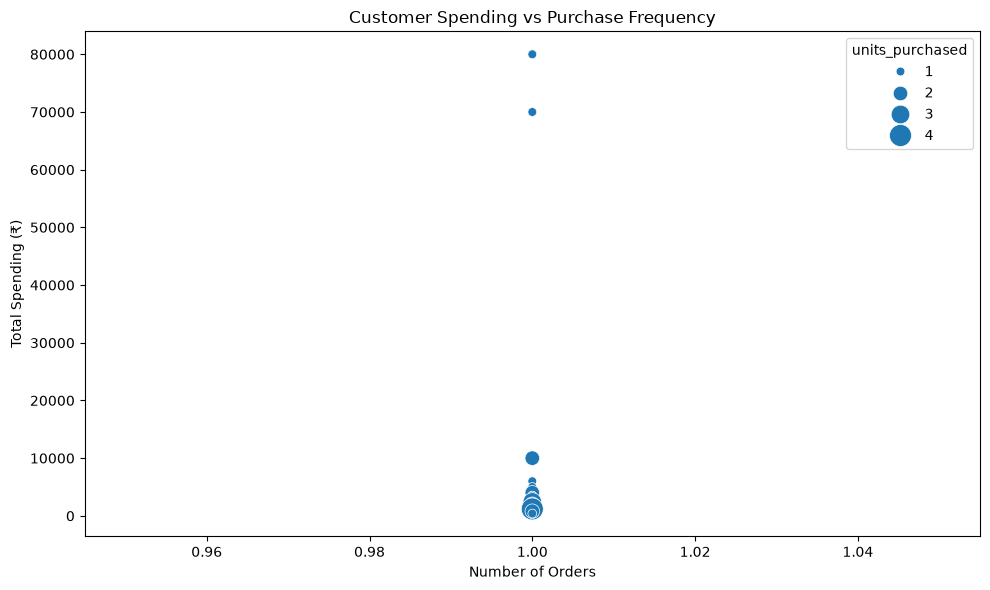

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_metrics,
    x="total_orders",
    y="total_spending",
    size="units_purchased",
    sizes=(40, 250)
)

plt.title("Customer Spending vs Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Total Spending (₹)")
plt.tight_layout()
plt.show()